# Off-the-grid deconvolution of a signed measure (kernel moment–SoS)

Recover a **gridless discrete signed measure** $\mu^\star=\sum_k a_k\delta_{t_k}$ (signs $a_k\in\mathbb R$)
from a **noisy, grid-sampled Gaussian convolution** $y=G_\sigma\star\mu^\star$ observed on a 2-D grid,
by the kernel moment–SoS BLASSO of §6 (diagonal / exact-kernel regime, Remark on the diagonal limit).

**Why this is the §6 apparatus.** $G_\sigma(s-t)=c_s\,e^{\langle s,t\rangle/\sigma^2}\,\omega^2(t)$ with the
tilting weight $\omega^2(t)=e^{-\|t\|^2/2\sigma^2}$, so each grid measurement
$(G_\sigma\star\mu)(s)=c_s\!\int e^{\langle s,t\rangle/\sigma^2}\mathrm d\nu(t)$, $\nu=\omega^2\mu$, is a
tilted-moment functional, with real Gaussian features in place of the complex Fourier features of §6.5.
The signed target exercises the Jordan split $\mu=\mu_+-\mu_-$ ($y_+,y_-$).

**Pipeline.** Grid samples → **raw-moment deconvolution** ($\int s^\alpha y\,\mathrm ds$, a Gaussian
lower-triangular system) → **signed diagonal moment SDP** ($y_+,y_-$) → **Curto–Fialkow** extraction.

**Noise regime (finding).** Signed recovery is more noise-demanding than the positive (GMM) case:
resolving the $y_+/y_-$ split needs higher-degree moments (here degree 6), which amplify noise. At
$\sigma=0.1$, with the ranks read at the fixed relative tolerance `RANK_TOL` $=3\times10^{-2}$ on the singular
values, the rank-2/rank-1 recovery holds at 40 dB and fails at 30 dB (the sweep of Section 10). This transition is
that of the fixed tolerance, not of the rank structure: in the 22 draws at 40 to 30 dB the normalised singular
values that vanish for $\mu^\star$ stay below $0.11$ and those kept exceed $0.55$, and at any tolerance from $0.11$
to $0.2$ every draw flat-extracts (Section 13). (The full grid QSDP is intractable here: the moment–SoS
lift needs $e^{\langle s,t\rangle/\sigma^2}$ with exponent $\sim10^2$.) We run at 40 dB; `SNR_DB` is a knob.

**Noise level.** `SNR_DB` fixes the per-sample standard deviation of the i.i.d. Gaussian grid noise,
`eta` $=\mathrm{rms}(y)/10^{\mathrm{SNR}/20}$, i.e. $\mathrm{SNR}=20\log_{10}(\mathrm{rms}(y)/\texttt{eta})$ dB, so that
$\|\varepsilon\|/\|y\|\approx10^{-\mathrm{SNR}/20}$ ($10^{-2}$ at 40 dB).

Section 11 prints the numbers quoted in §6.6 and in Remarks `rem:signed-noise` and `rem:deconv-christoffel`
(gaps, certificate values, sweep failure modes, H1 error ratios, variance spans, the GLS probe, the
degree-4 fit); Section 12 lists every solver status.

In [1]:
import sys, subprocess
try:
    import numpy, scipy, matplotlib, cvxpy  # noqa
except Exception:
    subprocess.check_call([sys.executable,"-m","pip","install","-q","numpy","scipy","matplotlib","cvxpy"])
# Versions used for the stored outputs (also listed in requirements.txt):
import numpy, matplotlib, cvxpy, clarabel, scs
print("python", sys.version.split()[0], "| numpy", numpy.__version__, "| matplotlib", matplotlib.__version__,
      "| cvxpy", cvxpy.__version__, "| clarabel", clarabel.__version__, "| scs", scs.__version__)

python 3.13.3 | numpy 2.3.3 | matplotlib 3.10.6 | cvxpy 1.9.1 | clarabel 0.11.1 | scs 3.2.11


## 1. Configuration

In [2]:
import os, math
import numpy as np
import matplotlib.pyplot as plt

ATOMS = np.array([[-0.6,-0.6],[0.6,0.6],[0.6,-0.6]])   # 3 gridless spikes
AMPS  = np.array([1.0, 0.7, -0.8])                     # signed amplitudes (2 positive, 1 negative)
SIGMA = 0.1                                            # Gaussian convolution width
BOX   = 1.2                                            # domain X = [-BOX,BOX]^2 and observation window
GRID  = 65                                             # measurement grid (GRID x GRID)
SNR_DB= 40                                             # additive Gaussian noise on the grid samples
D_ORDER = 8                                            # moment-matrix order
D_DATA  = 6                                            # moment-fit degree (degree 6 pins the signed split)
RANK_TOL= 3e-2
BETA    = 1e-3
EPS_CDK = 0.25                                        # Christoffel (H1) penalised-threshold gap
BETA_CDK= 1e-3                                        # Christoffel regularisation
N_CDK   = 6                                           # H1 re-solves (both Jordan blocks)
SNR_RESCUE = 30                                       # sub-threshold SNR for the Christoffel-rescue demo
SEED    = 0
rng=np.random.default_rng(SEED)
def monomials_upto(d):
    m=[(a,t-a) for t in range(d+1) for a in range(t+1)]; return m,{e:i for i,e in enumerate(m)}
MAXDEG=2*D_ORDER; MONOS,IDX=monomials_upto(MAXDEG)
def lam(al):  # Gaussian-Mercer metric
    a,b=al; return 1.0/(math.factorial(a)*math.factorial(b)*(2*SIGMA**2)**(a+b))
print(f"{len(ATOMS)} signed spikes; sigma={SIGMA}; grid {GRID}x{GRID}; SNR={SNR_DB} dB; "
      f"D_ORDER={D_ORDER} ({math.comb(D_ORDER+2,2)}x{math.comb(D_ORDER+2,2)} moment matrix), D_DATA={D_DATA}")

3 signed spikes; sigma=0.1; grid 65x65; SNR=40 dB; D_ORDER=8 (45x45 moment matrix), D_DATA=6


## 2. Forward model: noisy grid samples of $G_\sigma\star\mu^\star$

The noise is i.i.d. Gaussian on the grid with standard deviation `eta` $=\mathrm{rms}(y)/10^{\mathrm{SNR}/20}$
(`SNR_DB` in dB). The printed ||eps||/||y|| is the nominal ratio $\sqrt{N}\,$`eta`$/\|y\|=10^{-\mathrm{SNR}/20}$ ($N=65^2$);
Section 11 prints the realised one.
(`eta` here is the noise level; the certificate $\eta(x)$ of Section 8 is a different object.)

In [3]:
gx=np.linspace(-BOX,BOX,GRID); SXg,SYg=np.meshgrid(gx,gx)
S=np.column_stack([SXg.ravel(),SYg.ravel()]); dx=gx[1]-gx[0]
def Gsig2(d2): return np.exp(-d2/(2*SIGMA**2))/(2*np.pi*SIGMA**2)
y=np.zeros(len(S))
for a,t in zip(AMPS,ATOMS): y += a*Gsig2(np.sum((S-t)**2,axis=1))
eta=np.sqrt(np.mean(y**2))/(10**(SNR_DB/20))           # per-sample std for the target SNR
ynoisy=y+eta*rng.standard_normal(len(S))
print(f"dx={dx:.4f}, rms(y)={np.sqrt(np.mean(y**2)):.3f}, noise std eta={eta:.4f}, "
      f"||eps||/||y||={np.linalg.norm(eta*np.ones(len(S)))/np.linalg.norm(y):.4f}")

dx=0.0375, rms(y)=1.689, noise std eta=0.0169, ||eps||/||y||=0.0100


## 3. Raw-moment deconvolution

$\int s^\alpha y(s)\,\mathrm ds=\int \mathbb E_{U\sim G_\sigma}[(t+U)^\alpha]\,\mathrm d\mu(t)$ is
**lower-triangular** in the mixing moments $m_\beta=\int t^\beta\mathrm d\mu$ (Gaussian moments
$\mathbb E[U_i^k]=\sigma^k(k-1)!!$). We estimate $\int s^\alpha y\approx\Delta^2\sum_g s_g^\alpha\,\tilde y_g$
and invert. Unbiased, and (unlike CF-band deconvolution) noise is **not** amplified by $1/\widehat G_\sigma$.

In [4]:
def raw_deconv_moments(yv):
    cols=[e for e in MONOS if e[0]+e[1]<=D_DATA]
    my=np.array([(dx**2)*np.sum(S[:,0]**e[0]*S[:,1]**e[1]*yv) for e in cols])
    def muZ(k): return (0.0 if k%2 else float(math.prod(range(1,k,2)))*SIGMA**k) if k>0 else 1.0
    n=len(cols); L=np.zeros((n,n))
    for ia,a in enumerate(cols):
        for ib,b in enumerate(cols):
            if b[0]<=a[0] and b[1]<=a[1]:
                L[ia,ib]=math.comb(a[0],b[0])*math.comb(a[1],b[1])*muZ(a[0]-b[0])*muZ(a[1]-b[1])
    mm=np.linalg.solve(L,my); m=np.zeros(len(MONOS))
    for c,e in zip(mm,cols): m[IDX[e]]=c
    return m
mtrue=np.array([np.sum(AMPS*ATOMS[:,0]**e[0]*ATOMS[:,1]**e[1]) for e in MONOS])
mhat=raw_deconv_moments(ynoisy)
cols=[IDX[e] for e in MONOS if e[0]+e[1]<=D_DATA]
print(f"moment error (deg<= {D_DATA}): max |m_hat - m_true| = {np.max(np.abs(mhat[cols]-mtrue[cols])):.4f}")

moment error (deg<= 6): max |m_hat - m_true| = 0.0016


## 4. Signed diagonal moment SDP

$\min_{y_+,y_-}\ \tfrac12\sum_{|\alpha|\le d}\lambda_\alpha\big((y_+-y_-)_\alpha-\widehat m_\alpha\big)^2
+\beta\,(y_{+,0}+y_{-,0})$ s.t. $M_D(y_\pm)\succeq0$, box localisers $\succeq0$. The recovered measure is
$\mu=\mu_+-\mu_-$; $y_+$ holds the positive spikes, $y_-$ the negative ones.

In [5]:
def selector_moment(basis):
    nb=len(basis);T=np.zeros((nb*nb,len(IDX)))
    for a,ea in enumerate(basis):
        for b,eb in enumerate(basis):T[a*nb+b,IDX[(ea[0]+eb[0],ea[1]+eb[1])]]=1.0
    return T
def selector_localizing(basis,gt):
    nb=len(basis);T=np.zeros((nb*nb,len(IDX)))
    for a,ea in enumerate(basis):
        for b,eb in enumerate(basis):
            for co,sh in gt:T[a*nb+b,IDX[(ea[0]+eb[0]+sh[0],ea[1]+eb[1]+sh[1])]]+=co
    return T
SOLVE_LOG=[]   # one entry per cvxpy solve: (tag, solver, status, note)
def solve_signed_sdp(mh, cdkp=None, cdkm=None, tag="", fitw=None, fitR=None):
    """Signed diagonal SDP. Default fit metric: the Mercer weights lambda_alpha. fitw (vector) replaces them;
    fitR (matrix R) uses the fit 0.5*||R(diff-mh)||^2 instead (both only for the GLS probe of Section 11)."""
    import cvxpy as cp
    bD,_=monomials_upto(D_ORDER);bL,_=monomials_upto(D_ORDER-1);Tm=selector_moment(bD);b2=BOX**2
    Tl1=selector_localizing(bL,[(b2,(0,0)),(-1,(2,0))]);Tl2=selector_localizing(bL,[(b2,(0,0)),(-1,(0,2))])
    fc=[IDX[e] for e in MONOS if e[0]+e[1]<=D_DATA];w=np.array([lam(MONOS[k]) for k in fc])
    yp=cp.Variable(len(MONOS));ym=cp.Variable(len(MONOS));df=yp-ym;nD,nL=len(bD),len(bL)
    Mp=cp.reshape(Tm@yp,(nD,nD),order="C");Mm=cp.reshape(Tm@ym,(nD,nD),order="C")
    cons=[Mp>>0, Mm>>0,
          cp.reshape(Tl1@yp,(nL,nL),order="C")>>0, cp.reshape(Tl2@yp,(nL,nL),order="C")>>0,
          cp.reshape(Tl1@ym,(nL,nL),order="C")>>0, cp.reshape(Tl2@ym,(nL,nL),order="C")>>0]
    if cdkp is not None: cons.append(cp.sum(cp.multiply(cdkp[0],Mp))<=cdkp[1])   # H1 Christoffel on y_+
    if cdkm is not None: cons.append(cp.sum(cp.multiply(cdkm[0],Mm))<=cdkm[1])   # H1 Christoffel on y_-
    if fitw is not None: w=np.asarray(fitw,float)
    if fitR is None:
        obj=0.5*cp.sum(cp.multiply(w,cp.square(df[fc]-mh[fc])))+BETA*(yp[IDX[(0,0)]]+ym[IDX[(0,0)]])
    else:
        obj=0.5*cp.sum_squares(fitR@(df[fc]-mh[fc]))+BETA*(yp[IDX[(0,0)]]+ym[IDX[(0,0)]])
    prob=cp.Problem(cp.Minimize(obj),cons)
    try:
        prob.solve(solver=cp.CLARABEL,time_limit=180.0)
        if yp.value is None: raise Exception(f"no primal value (status {prob.status})")
        SOLVE_LOG.append((tag,"CLARABEL",prob.status,""))
    except Exception as e:
        msg=(str(e).split(". ")[0] or type(e).__name__)[:90]
        SOLVE_LOG.append((tag,"CLARABEL","failed",msg)); print(f"  [{tag}] CLARABEL failed ({msg}); falling back to SCS")
        try: prob.solve(solver=cp.SCS,max_iters=30000)
        except Exception as e2:
            msg2=(str(e2).split(". ")[0] or type(e2).__name__)[:90]
            SOLVE_LOG.append((tag,"SCS","failed",msg2)); print(f"  [{tag}] SCS failed ({msg2})")
            return None,None,bD
        SOLVE_LOG.append((tag,"SCS",prob.status,"fallback")); print(f"  [{tag}] SCS status={prob.status}")
    return yp.value,ym.value,bD
def moment_matrix(yv,bD):
    nb=len(bD);M=np.empty((nb,nb))
    for a,ea in enumerate(bD):
        for b,eb in enumerate(bD):M[a,b]=yv[IDX[(ea[0]+eb[0],ea[1]+eb[1])]]
    return M
def christoffel_weight(M,beta):
    """H1 datum: W=(M+beta I)^{-1}, L=tr(WM)=sum e_i/(e_i+beta) (rank surrogate)."""
    W=np.linalg.inv(M+beta*np.eye(M.shape[0])); return W,float(np.sum(W*M))

## 5. Curto–Fialkow extraction (signed: from $y_+$ and $y_-$ separately)

In [6]:
def _rref_pivots(M,tol):
    A=M.copy().astype(float);nr,nc=A.shape;piv,row=[],0
    for col in range(nc):
        if row>=nr:break
        p=row+np.argmax(np.abs(A[row:,col]))
        if abs(A[p,col])<=tol:continue
        A[[row,p]]=A[[p,row]];A[row]/=A[row,col]
        for rr in range(nr):
            if rr!=row:A[rr]-=A[rr,col]*A[row]
        piv.append(col);row+=1
    return piv
def extract_atoms(M,bD):
    pos={e:i for i,e in enumerate(bD)};deg=[e[0]+e[1] for e in bD]
    s=np.linalg.svd(M,compute_uv=False);rank=int(np.sum(s>RANK_TOL*s[0]))
    if rank<1:return np.zeros((0,2)),np.zeros(0)
    piv=[p for p in _rref_pivots(M,RANK_TOL*s[0]) if deg[p]<=D_ORDER-1];piv=sorted(piv,key=lambda i:(deg[i],i))
    if len(piv)<rank:raise RuntimeError(f"not flat: rank {rank}, {len(piv)} low-deg pivots")
    pv=piv[:rank];B=[bD[i] for i in pv];Mpp=M[np.ix_(pv,pv)];mult=[]
    for k in range(2):
        Nk=np.zeros((rank,rank))
        for j,be in enumerate(B):
            sh=(be[0]+(1 if k==0 else 0),be[1]+(1 if k==1 else 0));si=pos.get(sh)
            if si is None:raise RuntimeError("shift outside basis")
            Nk[:,j]=np.linalg.solve(Mpp,np.array([M[pv[i],si] for i in range(rank)]))
        mult.append(Nk)
    g=np.random.default_rng(1).standard_normal(2);_,V=np.linalg.eig(g[0]*mult[0]+g[1]*mult[1]);Vi=np.linalg.inv(V)
    coords=np.column_stack([np.real(np.diag(Vi@mult[k]@V)) for k in range(2)])
    Phi=np.array([[a[0]**e[0]*a[1]**e[1] for a in coords] for e in B],float)
    wt,*_=np.linalg.lstsq(Phi,np.array([M[pv[i],pos[(0,0)]] for i in range(rank)]),rcond=None)
    return coords,wt

## 6. Run and summarise

In [7]:
yp,ym,bD=solve_signed_sdp(mhat,tag="40 dB main")
print(f"solver: {SOLVE_LOG[-1][1]} status={SOLVE_LOG[-1][2]}")
Mp=moment_matrix(yp,bD); Mm=moment_matrix(ym,bD)
rec_atoms=[]; rec_amps=[]
for yy,bD_,sgn,lab in [(yp,bD,+1,"y+"),(ym,bD,-1,"y-")]:
    M=moment_matrix(yy,bD_)
    try:
        a,wt=extract_atoms(M,bD_)
        keep=np.abs(wt)>1e-2*max(np.max(np.abs(wt)) if len(wt) else 1, 1e-12)
        for c,w in zip(a[keep],wt[keep]): rec_atoms.append(c); rec_amps.append(sgn*float(w))
        sv=np.linalg.svd(M,compute_uv=False); print(f"{lab}: rank {int(np.sum(sv>RANK_TOL*sv[0]))}, svals[:4]={np.round(sv[:4]/sv[0],4)}")
    except Exception as e: print(f"{lab}: {e}")
rec_atoms=np.array(rec_atoms); rec_amps=np.array(rec_amps)
print("\nTRUE :", [(round(t[0],2),round(t[1],2),round(a,2)) for t,a in zip(ATOMS,AMPS)])
for t,a in zip(ATOMS,AMPS):
    if len(rec_atoms):
        j=int(np.argmin([np.hypot(*(r-t)) for r in rec_atoms])); r=rec_atoms[j]
        print(f"  true ({t[0]:+.2f},{t[1]:+.2f}) a={a:+.2f}  ->  rec ({r[0]:+.3f},{r[1]:+.3f}) a={rec_amps[j]:+.3f}  | dpos={np.hypot(*(r-t)):.3f} da={abs(rec_amps[j]-a):.3f}")

solver: CLARABEL status=optimal_inaccurate
y+: rank 2, svals[:4]=[1.     0.5643 0.021  0.0082]
y-: rank 1, svals[:4]=[1.     0.0256 0.0118 0.0039]

TRUE : [(np.float64(-0.6), np.float64(-0.6), np.float64(1.0)), (np.float64(0.6), np.float64(0.6), np.float64(0.7)), (np.float64(0.6), np.float64(-0.6), np.float64(-0.8))]
  true (-0.60,-0.60) a=+1.00  ->  rec (-0.600,-0.600) a=+1.000  | dpos=0.000 da=0.000
  true (+0.60,+0.60) a=+0.70  ->  rec (+0.598,+0.602) a=+0.700  | dpos=0.002 da=0.000
  true (+0.60,-0.60) a=-0.80  ->  rec (+0.599,-0.599) a=-0.801  | dpos=0.002 da=0.001


/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


## 7. Figures → `../figs/` (displayed inline)

saved fig_deconv_2d_a.pdf


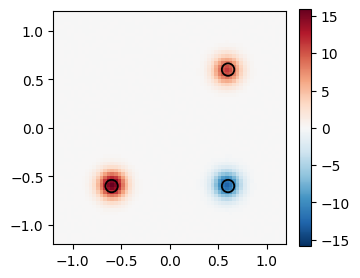

saved fig_deconv_2d_b.pdf


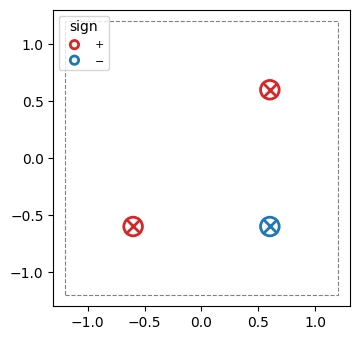

saved fig_deconv_2d_c.pdf -> ../figs


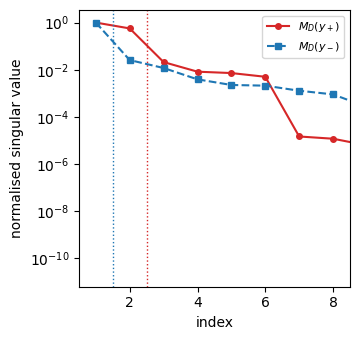

In [8]:
FIGS=os.path.abspath("../figs" if os.path.basename(os.getcwd())=="code" else "figs"); os.makedirs(FIGS,exist_ok=True)
# (a) noisy observation
fig,ax=plt.subplots(figsize=(3.7,3.5))
im=ax.imshow(ynoisy.reshape(GRID,GRID),extent=[-BOX,BOX,-BOX,BOX],origin="lower",cmap="RdBu_r",
             vmin=-np.max(np.abs(ynoisy)),vmax=np.max(np.abs(ynoisy)))
ax.scatter(ATOMS[:,0],ATOMS[:,1],s=80,facecolors="none",edgecolors="k",lw=1.3)
fig.colorbar(im,ax=ax,fraction=.046)
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_deconv_2d_a.pdf"),bbox_inches="tight"); print("saved fig_deconv_2d_a.pdf"); plt.show()
# (b) recovery (signed)
fig,ax=plt.subplots(figsize=(3.7,3.5))
for t,a in zip(ATOMS,AMPS):
    ax.scatter(t[0],t[1],s=180,facecolors="none",edgecolors=("C3" if a>0 else "C0"),lw=2)
for r,a in zip(rec_atoms,rec_amps):
    ax.scatter(r[0],r[1],s=90,marker="x",c=("C3" if a>0 else "C0"),lw=2)
ax.add_patch(plt.Rectangle((-BOX,-BOX),2*BOX,2*BOX,fill=False,ec=".5",ls="--",lw=.8))
ax.set_xlim(-BOX-.1,BOX+.1); ax.set_ylim(-BOX-.1,BOX+.1); ax.set_aspect("equal")
ax.scatter([],[],facecolors="none",edgecolors="C3",label="+",lw=2); ax.scatter([],[],facecolors="none",edgecolors="C0",label="$-$",lw=2)
ax.legend(loc="upper left",fontsize=8,title="sign")
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_deconv_2d_b.pdf"),bbox_inches="tight"); print("saved fig_deconv_2d_b.pdf"); plt.show()
# (c) singular values of M_D(y+), M_D(y-)
fig,ax=plt.subplots(figsize=(3.7,3.5))
for M,st,lab,col in [(Mp,"o-","$M_D(y_+)$","C3"),(Mm,"s--","$M_D(y_-)$","C0")]:   # red = +, blue = -
    sv=np.linalg.svd(M,compute_uv=False); ax.semilogy(np.arange(1,len(sv)+1),sv/sv[0],st,ms=4,color=col,label=lab)
ax.axvline(2.5,color="C3",ls=":",lw=1); ax.axvline(1.5,color="C0",ls=":",lw=1)
ax.set_xlim(0.5,8.5); ax.set_xlabel("index"); ax.set_ylabel("normalised singular value")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_deconv_2d_c.pdf"),bbox_inches="tight"); print("saved fig_deconv_2d_c.pdf ->",os.path.relpath(FIGS)); plt.show()

## 8. Dual certificate at 40 dB

The subgradient certificate $\eta(x)=\tfrac1\beta\sum_{|\alpha|\le D_{\rm data}}\lambda_\alpha(\widehat m_\alpha-(y_+-y_-)_\alpha)\,x^\alpha$
(the back-projected residual). At the BLASSO optimum $\|\eta\|_\infty\le1$ and $\eta(t_k)=\mathrm{sign}(a_k)$:
$+1$ at the two positive spikes, $-1$ at the negative one.

eta at the 3 spikes: [ 1.  1. -1.]  (target signs [ 1  1 -1] ); max|eta|= 1.0


saved fig_deconv_2d_cert.pdf


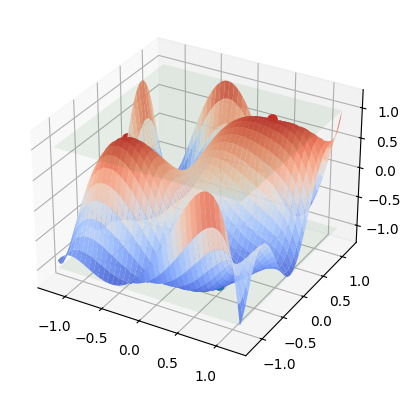

In [9]:
def certificate(mh,yp_,ym_,pts):
    diff=yp_-ym_; coef=np.zeros(len(MONOS))
    for e in MONOS:
        if e[0]+e[1]<=D_DATA: coef[IDX[e]]=lam(e)*(mh[IDX[e]]-diff[IDX[e]])/BETA
    return np.array([sum(coef[IDX[e]]*p[0]**e[0]*p[1]**e[1] for e in MONOS) for p in np.atleast_2d(pts)])
gc=np.linspace(-BOX,BOX,80); EX,EY=np.meshgrid(gc,gc); egrid=np.column_stack([EX.ravel(),EY.ravel()])
eta=certificate(mhat,yp,ym,egrid).reshape(EX.shape)
print("eta at the 3 spikes:",np.round(certificate(mhat,yp,ym,ATOMS),3)," (target signs",np.sign(AMPS).astype(int),"); max|eta|=",round(float(np.max(np.abs(eta))),3))
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig=plt.figure(figsize=(5.0,4.0)); ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(EX,EY,eta,cmap="coolwarm",alpha=.92,linewidth=0,antialiased=True,vmin=-1.1,vmax=1.1)
ax.plot_surface(EX,EY,np.ones_like(EX),color="g",alpha=.07,linewidth=0)
ax.plot_surface(EX,EY,-np.ones_like(EX),color="g",alpha=.07,linewidth=0)
for t,a in zip(ATOMS,AMPS): ax.scatter([t[0]],[t[1]],[np.sign(a)],c=("C3" if a>0 else "C0"),s=45,depthshade=False)
ax.set_zlim(-1.3,1.3)
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_deconv_2d_cert.pdf"),bbox_inches="tight"); print("saved fig_deconv_2d_cert.pdf"); plt.show()

## 9. Christoffel correction at 30 dB

On this 30 dB draw the plain signed program does not flat-extract at `RANK_TOL` (numerical ranks 4 and 3). The
**H1 Christoffel rank-cap** of Section 5.3, applied to *both* Jordan blocks
($L_y(\widetilde\Lambda_D^{y^\star_\pm})\le(1-\varepsilon)L_{y^\star_\pm}(\widetilde\Lambda_D^{y^\star_\pm})$, iterated),
lowers the singular values that vanish for $\mu^\star$ under `RANK_TOL`, so that the ranks read there fall to
$2$ / $1$. It moves the small singular values under the tolerance rather than removing noise: read at $0.11$, the
plain program recovers this draw with smaller errors than H1 (Section 13, 13e). Every solve prints its solver when Clarabel
fails and SCS takes over; cell 20 lists the statuses. The GLS / inverse-variance reweighting of the moment fit
is run in Section 11.

  [30 dB H1 1] CLARABEL failed (Solver 'CLARABEL' failed); falling back to SCS


  [30 dB H1 1] SCS status=optimal


  [30 dB H1 2] CLARABEL failed (Solver 'CLARABEL' failed); falling back to SCS


/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:40: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  try: prob.solve(solver=cp.SCS,max_iters=30000)


  [30 dB H1 2] SCS status=optimal_inaccurate


...

  [30 dB H1 4] SCS status=optimal


  [30 dB H1 5] CLARABEL failed (Solver 'CLARABEL' failed); falling back to SCS


  [30 dB H1 5] SCS status=optimal_inaccurate


  [30 dB H1 6] CLARABEL failed (Solver 'CLARABEL' failed); falling back to SCS


  [30 dB H1 6] SCS status=optimal_inaccurate
30 dB:  base rk(y+)=4 rk(y-)=3   ->   H1 rk(y+)=2 rk(y-)=1
saved fig_deconv_2d_h1.pdf


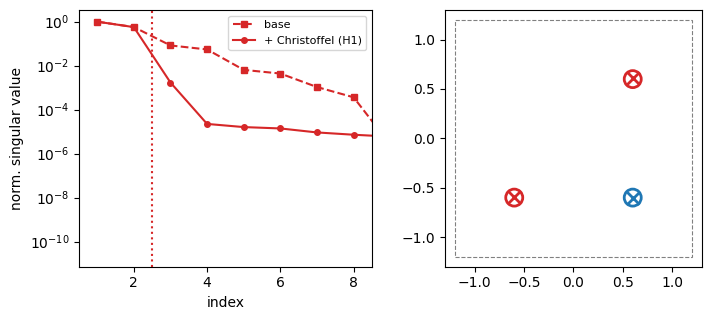

In [10]:
rngR=np.random.default_rng(SEED+1)
etaR=np.sqrt(np.mean(y**2))/(10**(SNR_RESCUE/20)); yR=y+etaR*rngR.standard_normal(len(S))
mhatR=raw_deconv_moments(yR)
ypb,ymb,bD=solve_signed_sdp(mhatR,tag=f"{SNR_RESCUE} dB base")   # base (expected to fail sub-threshold)
yps,yms=ypb.copy(),ymb.copy()
n_h1=0
for it in range(N_CDK):
    Wp,Lp=christoffel_weight(moment_matrix(yps,bD),BETA_CDK)
    Wm,Lm=christoffel_weight(moment_matrix(yms,bD),BETA_CDK)
    o=solve_signed_sdp(mhatR,cdkp=(Wp,(1-EPS_CDK)*Lp),cdkm=(Wm,(1-EPS_CDK)*Lm),tag=f"{SNR_RESCUE} dB H1 {it+1}")
    if o[0] is None:
        print(f"H1 re-solve {it+1}: no primal value, stop"); break
    yps,yms=o[0],o[1]; n_h1=it+1
def rk(M): sv=np.linalg.svd(M,compute_uv=False); return int(np.sum(sv>RANK_TOL*sv[0]))
print(f"{SNR_RESCUE} dB:  base rk(y+)={rk(moment_matrix(ypb,bD))} rk(y-)={rk(moment_matrix(ymb,bD))}"
      f"   ->   H1 rk(y+)={rk(moment_matrix(yps,bD))} rk(y-)={rk(moment_matrix(yms,bD))}")
fig,axs=plt.subplots(1,2,figsize=(7.4,3.3))
for M,st,labl in [(moment_matrix(ypb,bD),"s--","base"),(moment_matrix(yps,bD),"o-","+ Christoffel (H1)")]:
    sv=np.linalg.svd(M,compute_uv=False); axs[0].semilogy(np.arange(1,len(sv)+1),sv/sv[0],st,ms=4,color="C3",label=labl)
axs[0].axvline(2.5,color="C3",ls=":"); axs[0].set_xlim(0.5,8.5); axs[0].set_xlabel("index"); axs[0].set_ylabel("norm. singular value")
axs[0].legend(fontsize=8)
for yy,sgn in [(yps,1),(yms,-1)]:
    try:
        a,wt=extract_atoms(moment_matrix(yy,bD),bD); keep=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-9)
        axs[1].scatter(a[keep,0],a[keep,1],marker="x",c=("C3" if sgn>0 else "C0"),s=80,lw=2)
    except Exception as e: print(f"H1 extraction ({'y+' if sgn>0 else 'y-'}) failed: {e}")
for t,a in zip(ATOMS,AMPS): axs[1].scatter(t[0],t[1],facecolors="none",edgecolors=("C3" if a>0 else "C0"),s=150,lw=2)
axs[1].add_patch(plt.Rectangle((-BOX,-BOX),2*BOX,2*BOX,fill=False,ec=".5",ls="--",lw=.8))
axs[1].set_xlim(-BOX-.1,BOX+.1); axs[1].set_ylim(-BOX-.1,BOX+.1); axs[1].set_aspect("equal")
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_deconv_2d_h1.pdf"),bbox_inches="tight"); print("saved fig_deconv_2d_h1.pdf"); plt.show()

In [11]:
# H1 rescue at 30 dB: recovered atoms, errors and solver statuses (base solve vs the six H1 re-solves)
for yy,sgn,lab in [(yps,1,"y+"),(yms,-1,"y-")]:
    try:
        a,wt=extract_atoms(moment_matrix(yy,bD),bD); keep=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-9)
        for c,w in zip(a[keep],wt[keep]):
            j=int(np.argmin([np.hypot(*(c-t)) for t in ATOMS])); print(f"{lab}: atom ({c[0]:+.3f},{c[1]:+.3f}) a={sgn*w:+.3f}  | dpos={np.hypot(*(c-ATOMS[j])):.1e} da={abs(sgn*w-AMPS[j]):.1e}")
    except Exception as e: print(f"{lab}: {e}")
print(f"H1: {n_h1} of N_CDK={N_CDK} re-solves completed")
for tag,solver,status,note in SOLVE_LOG:
    if tag.startswith(f"{SNR_RESCUE} dB"): print(f"  {tag:12s} {solver:9s} {status}" + (f"  ({note})" if note else ""))

y+: atom (-0.601,-0.598) a=+0.994  | dpos=1.9e-03 da=5.9e-03
y+: atom (+0.602,+0.608) a=+0.683  | dpos=8.6e-03 da=1.7e-02
y-: atom (+0.599,-0.602) a=-0.799  | dpos=2.3e-03 da=1.4e-03
H1: 6 of N_CDK=6 re-solves completed
  30 dB base   CLARABEL  optimal
  30 dB H1 1   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 1   SCS       optimal  (fallback)
  30 dB H1 2   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 2   SCS       optimal_inaccurate  (fallback)
  30 dB H1 3   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 3   SCS       optimal  (fallback)
  30 dB H1 4   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 4   SCS       optimal  (fallback)
  30 dB H1 5   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 5   SCS       optimal_inaccurate  (fallback)
  30 dB H1 6   CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 6   SCS       optimal_inaccurate  (fallback)


## 10. SNR sweep at the fixed tolerance

Fresh noise draws of the base program (no Christoffel step) at 45 to 30 dB. A case succeeds when $y_+$ flat-extracts
two atoms and $y_-$ one, at the tolerance `RANK_TOL` on the normalised singular values. Section 11 adds the main 40 dB
draw and the 30 dB draw of Section 9 to the counts, as Remark `rem:signed-noise` does.

In [12]:
# SNR sweep (base program, fresh noise draws): where does the flat extraction stop working?
# Each case: noise draw rng(100+seed) at the given SNR, raw-moment deconvolution, signed SDP,
# extraction from y+ and y-; a case "succeeds" when y+ gives 2 atoms and y- gives 1.
import time
def rank_tol(M): sv=np.linalg.svd(M,compute_uv=False); return int(np.sum(sv>RANK_TOL*sv[0])), sv[:4]/sv[0]
cases=[(45,0),(45,1),(45,2),(40,1),(40,2),(40,3),(40,4),(40,5),(40,6),(37,0),(37,1),(37,2),(35,0),(35,1),(35,2),(35,3),(35,4),(32,0),(32,1),(32,2),(30,1),(30,2),(30,3)]
summary={}; sweep_rec={}
for snr,seed in cases:
    t0=time.time(); rng_s=np.random.default_rng(100+seed)
    e_s=np.sqrt(np.mean(y**2))/(10**(snr/20)); y_s=y+e_s*rng_s.standard_normal(len(S))
    yp_s,ym_s,bD_s=solve_signed_sdp(raw_deconv_moments(y_s),tag=f"sweep {snr} dB seed {seed}")
    ok=[]; line=[]; svs={}
    for yy,sgn,lab,want in [(yp_s,1,"y+",2),(ym_s,-1,"y-",1)]:
        M=moment_matrix(yy,bD_s); r,sv=rank_tol(M); svs[lab]=sv
        try:
            a,wt=extract_atoms(M,bD_s); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-12); n=int(k.sum())
            line.append(f"{lab}: sv={np.round(sv,4)} -> {n} atoms"); ok.append(n==want)
        except Exception as ex:
            line.append(f"{lab}: sv={np.round(sv,4)} -> {ex}"); ok.append(False)
    summary.setdefault(snr,[]).append(all(ok)); sweep_rec[(snr,seed)]=dict(ok=all(ok),svp=svs["y+"],svm=svs["y-"])
    print(f"SNR {snr} dB, seed {seed} ({time.time()-t0:.0f}s): {'success' if all(ok) else 'FAIL'};  "+" | ".join(line))
print("\nsuccess rate per SNR (this sweep):", {k:f"{sum(v)}/{len(v)}" for k,v in sorted(summary.items(),reverse=True)})


/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


SNR 45 dB, seed 0 (2s): success;  y+: sv=[1.     0.5621 0.0085 0.0039] -> 2 atoms | y-: sv=[1.     0.0135 0.0046 0.0038] -> 1 atoms


SNR 45 dB, seed 1 (2s): success;  y+: sv=[1.     0.5619 0.0063 0.003 ] -> 2 atoms | y-: sv=[1.     0.0071 0.0066 0.0028] -> 1 atoms


SNR 45 dB, seed 2 (2s): success;  y+: sv=[1.     0.5618 0.0113 0.0059] -> 2 atoms | y-: sv=[1.     0.0113 0.0047 0.0039] -> 1 atoms


SNR 40 dB, seed 1 (2s): success;  y+: sv=[1.     0.5622 0.011  0.0052] -> 2 atoms | y-: sv=[1.     0.0131 0.012  0.0048] -> 1 atoms


...

SNR 32 dB, seed 1 (2s): FAIL;  y+: sv=[1.     0.5631 0.0276 0.013 ] -> 2 atoms | y-: sv=[1.     0.0348 0.0321 0.0118] -> not flat: rank 3, 1 low-deg pivots


SNR 32 dB, seed 2 (2s): FAIL;  y+: sv=[1.     0.5628 0.0486 0.0256] -> not flat: rank 3, 2 low-deg pivots | y-: sv=[1.     0.052  0.0204 0.0166] -> not flat: rank 2, 1 low-deg pivots


SNR 30 dB, seed 1 (2s): FAIL;  y+: sv=[1.     0.5635 0.0347 0.0163] -> not flat: rank 3, 2 low-deg pivots | y-: sv=[1.     0.0445 0.0409 0.0148] -> not flat: rank 3, 1 low-deg pivots


SNR 30 dB, seed 2 (2s): FAIL;  y+: sv=[1.     0.5631 0.0609 0.032 ] -> not flat: rank 4, 2 low-deg pivots | y-: sv=[1.     0.0653 0.0256 0.0207] -> not flat: rank 2, 1 low-deg pivots


SNR 30 dB, seed 3 (2s): FAIL;  y+: sv=[1.     0.5596 0.0128 0.0074] -> 2 atoms | y-: sv=[1.     0.0561 0.0305 0.002 ] -> not flat: rank 3, 1 low-deg pivots

success rate per SNR (this sweep): {45: '3/3', 40: '5/6', 37: '2/3', 35: '1/5', 32: '0/3', 30: '0/3'}


## 11. Numbers quoted in §6.6 and Remarks `rem:signed-noise`, `rem:deconv-christoffel`

These cells print the values that the text quotes, from the runs above. They do not change any result or
figure above; the extra solves (GLS probe, degree-4 fit) are logged in Section 12.

In [13]:
# §6.6 at 40 dB: realised noise level, singular-value gaps at RANK_TOL (text: factor 27 for y+, 40 for y-),
# recovery errors (text: 2e-3 in position, 1e-3 in amplitude).
noise_std=np.sqrt(np.mean(y**2))/(10**(SNR_DB/20))
print(f"noise std = rms(y)/10^(SNR/20) = {noise_std:.5f}; realised ||eps||/||y|| = {np.linalg.norm(ynoisy-y)/np.linalg.norm(y):.4f}"
      f" (20 log10 ||y||/||eps|| = {20*np.log10(np.linalg.norm(y)/np.linalg.norm(ynoisy-y)):.2f} dB)")
svp=np.linalg.svd(Mp,compute_uv=False); svm=np.linalg.svd(Mm,compute_uv=False)
print(f"y+: s/s1 = {np.round(svp[:4]/svp[0],4)}, gap s2/s3 = {svp[1]/svp[2]:.1f}")
print(f"y-: s/s1 = {np.round(svm[:4]/svm[0],4)}, gap s1/s2 = {svm[0]/svm[1]:.1f}")
def spike_errors(atoms, amps):
    out=[]
    for t,a in zip(ATOMS,AMPS):
        j=int(np.argmin([np.hypot(*(r-t)) for r in atoms])); out.append((np.hypot(*(atoms[j]-t)),abs(amps[j]-a)))
    return np.array(out)
err40=spike_errors(rec_atoms,rec_amps)
print(f"40 dB: dpos = {[f'{v:.2e}' for v in err40[:,0]]}, da = {[f'{v:.2e}' for v in err40[:,1]]}; "
      f"max dpos = {err40[:,0].max():.2e}, max da = {err40[:,1].max():.2e}")

noise std = rms(y)/10^(SNR/20) = 0.01689; realised ||eps||/||y|| = 0.0100 (20 log10 ||y||/||eps|| = 40.02 dB)
y+: s/s1 = [1.     0.5643 0.021  0.0082], gap s2/s3 = 26.8
y-: s/s1 = [1.     0.0256 0.0118 0.0039], gap s1/s2 = 39.1
40 dB: dpos = ['2.65e-04', '2.21e-03', '1.99e-03'], da = ['3.55e-04', '3.93e-04', '1.38e-03']; max dpos = 2.21e-03, max da = 1.38e-03


In [14]:
# Certificate on a 161^2 grid of X (text: max|eta| = 1.00001, eta = +1, +1, -1 at the spikes, 0.99992 at the corner (1.2,1.2)).
c_eta=np.zeros(len(MONOS)); d_pm=yp-ym
for e in MONOS:
    if e[0]+e[1]<=D_DATA: c_eta[IDX[e]]=lam(e)*(mhat[IDX[e]]-d_pm[IDX[e]])/BETA
def eta_eval(P): return sum(c_eta[IDX[e]]*P[:,0]**e[0]*P[:,1]**e[1] for e in MONOS if e[0]+e[1]<=D_DATA)
g161=np.linspace(-BOX,BOX,161); G1,G2=np.meshgrid(g161,g161); P161=np.column_stack([G1.ravel(),G2.ravel()])
E161=eta_eval(P161); dist=np.min(np.linalg.norm(P161[:,None,:]-ATOMS[None,:,:],axis=2),axis=1)
print(f"max|eta| on the 161^2 grid = {np.abs(E161).max():.5f}; eta at the spikes = {np.round(eta_eval(ATOMS),5)}")
for r in (0.15,0.3):
    i=int(np.argmax(np.abs(E161)*(dist>r)))
    print(f"max|eta| at distance > {r} from every spike = {abs(E161[i]):.5f} at ({P161[i,0]:+.2f},{P161[i,1]:+.2f})")

max|eta| on the 161^2 grid = 1.00001; eta at the spikes = [ 1.       1.      -1.00001]
max|eta| at distance > 0.15 from every spike = 0.99992 at (+1.20,+1.20)
max|eta| at distance > 0.3 from every spike = 0.99992 at (+1.20,+1.20)


In [15]:
# Remark rem:signed-noise: success counts with the main 40 dB draw and the 30 dB draw of Section 9 added to the sweep,
# and, for every failure, which block crosses the tolerance (y-: 2nd singular value; y+: 3rd singular value).
def flat_ok(yp_, ym_, why=None):         # the sweep's criterion: y+ gives 2 atoms, y- gives 1
    res=[]
    for yy,want,nm in ((yp_,2,"y+"),(ym_,1,"y-")):
        try:
            a,wt=extract_atoms(moment_matrix(yy,bD),bD); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-12)
            res.append(int(k.sum())==want)
            if why is not None and int(k.sum())!=want: why.append(f"{nm}: {int(k.sum())} atoms")
        except Exception as ex:           # e.g. "not flat": a failure, as in the sweep; the reason is kept
            res.append(False)
            if why is not None: why.append(f"{nm}: {ex}")
    return all(res)
def s4(M): s=np.linalg.svd(M,compute_uv=False); return s[:4]/s[0]
why_main,why_resc=[],[]
rows=[(SNR_DB,"main",flat_ok(yp,ym,why_main),s4(Mp),s4(Mm)),
      (SNR_RESCUE,"Section 9",flat_ok(ypb,ymb,why_resc),s4(moment_matrix(ypb,bD)),s4(moment_matrix(ymb,bD)))]
print(f"main {SNR_DB} dB draw:", "success" if rows[0][2] else f"FAIL ({'; '.join(why_main)})",
      f"| {SNR_RESCUE} dB draw of Section 9, base program:", "success" if rows[1][2] else f"FAIL ({'; '.join(why_resc)})")
rows+=[(snr,f"seed {seed}",r["ok"],r["svp"],r["svm"]) for (snr,seed),r in sweep_rec.items()]
tally={}
for snr,_,ok,_,_ in rows: tally.setdefault(snr,[0,0]); tally[snr][0]+=int(ok); tally[snr][1]+=1
print("success per SNR (sweep + main 40 dB draw + 30 dB draw of Section 9):",
      {k:f"{v[0]}/{v[1]}" for k,v in sorted(tally.items(),reverse=True)},
      f"| 32 and 30 dB together: {tally[32][0]+tally[30][0]}/{tally[32][1]+tally[30][1]}")
fails=[r for r in rows if not r[2]]; tol=RANK_TOL
for snr,lab,_,sp,sm in fails:
    print(f"  FAIL {snr} dB {lab:9s}: y+ s3 = {sp[2]:.4f} ({'>' if sp[2]>tol else '<'} tol), y- s2 = {sm[1]:.4f} ({'>' if sm[1]>tol else '<'} tol)")
cm=[sm[1]>tol for *_,sp,sm in fails]; cp_=[sp[2]>tol for *_,sp,sm in fails]
print(f"{len(fails)} failures ({sum(1 for r in fails if r[1].startswith('seed'))} in the sweep): y- s2 > tol in {sum(cm)}, "
      f"y+ s3 > tol in {sum(cp_)}, both in {sum(a and b for a,b in zip(cm,cp_))}, y+ only in {sum(b and not a for a,b in zip(cm,cp_))}, "
      f"y- only in {sum(a and not b for a,b in zip(cm,cp_))}, neither in {sum(not a and not b for a,b in zip(cm,cp_))}")
succ=[r for r in rows if r[2]]
print(f"{len(succ)} successes: max y- s2 = {max(r[4][1] for r in succ):.4f}, max y+ s3 = {max(r[3][2] for r in succ):.4f} (tol {tol:g})")

main 40 dB draw: success | 30 dB draw of Section 9, base program: FAIL (y+: not flat: rank 4, 2 low-deg pivots; y-: not flat: rank 3, 1 low-deg pivots)
success per SNR (sweep + main 40 dB draw + 30 dB draw of Section 9): {45: '3/3', 40: '6/7', 37: '2/3', 35: '1/5', 32: '0/3', 30: '0/4'} | 32 and 30 dB together: 0/7
  FAIL 30 dB Section 9: y+ s3 = 0.0830 (> tol), y- s2 = 0.1068 (> tol)
  FAIL 40 dB seed 5   : y+ s3 = 0.0425 (> tol), y- s2 = 0.0163 (< tol)
  FAIL 37 dB seed 0   : y+ s3 = 0.0206 (< tol), y- s2 = 0.0350 (> tol)
  FAIL 35 dB seed 0   : y+ s3 = 0.0257 (< tol), y- s2 = 0.0447 (> tol)
  FAIL 35 dB seed 2   : y+ s3 = 0.0348 (> tol), y- s2 = 0.0367 (> tol)
  FAIL 35 dB seed 3   : y+ s3 = 0.0073 (< tol), y- s2 = 0.0308 (> tol)
  FAIL 35 dB seed 4   : y+ s3 = 0.0354 (> tol), y- s2 = 0.0418 (> tol)
  FAIL 32 dB seed 0   : y+ s3 = 0.0355 (> tol), y- s2 = 0.0646 (> tol)
  FAIL 32 dB seed 1   : y+ s3 = 0.0276 (< tol), y- s2 = 0.0348 (> tol)
  FAIL 32 dB seed 2   : y+ s3 = 0.0486 (> to

In [16]:
# Remark rem:deconv-christoffel: H1 errors at 30 dB (text: "to 1e-2 in position and amplitude, five to ten times the
# 40 dB errors") and their ratios to the 40 dB errors of the first cell of this section.
atH1=[]; amH1=[]
for yy,sgn in ((yps,1),(yms,-1)):
    a,wt=extract_atoms(moment_matrix(yy,bD),bD); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-9)
    atH1+=list(a[k]); amH1+=list(sgn*wt[k])
errH1=spike_errors(np.array(atH1),np.array(amH1))
print(f"30 dB H1: dpos = {[f'{v:.2e}' for v in errH1[:,0]]}, da = {[f'{v:.2e}' for v in errH1[:,1]]}")
print(f"max dpos: H1 30 dB {errH1[:,0].max():.2e} vs 40 dB {err40[:,0].max():.2e} -> ratio {errH1[:,0].max()/err40[:,0].max():.1f}")
print(f"max da  : H1 30 dB {errH1[:,1].max():.2e} vs 40 dB {err40[:,1].max():.2e} -> ratio {errH1[:,1].max()/err40[:,1].max():.1f}")

30 dB H1: dpos = ['1.93e-03', '8.56e-03', '2.33e-03'], da = ['5.90e-03', '1.72e-02', '1.40e-03']
max dpos: H1 30 dB 8.56e-03 vs 40 dB 2.21e-03 -> ratio 3.9
max da  : H1 30 dB 1.72e-02 vs 40 dB 1.38e-03 -> ratio 12.4


In [17]:
# Remark rem:deconv-christoffel, GLS probe. For i.i.d. grid noise of std s, m_hat = L^{-1} Delta^2 S_a^T y_noisy has
# Cov(m_hat) = s^2 Delta^4 L^{-1} S_a^T S_a L^{-T} (S_a: grid values of the monomials |alpha| <= D_DATA). The text quotes
# the span max/min of its diagonal (5 at sigma=0.1, 36 at sigma=0.3) and the span of the Mercer metric (10^8 at sigma=0.1).
cols6=[e for e in MONOS if e[0]+e[1]<=D_DATA]
Sa=np.column_stack([S[:,0]**e[0]*S[:,1]**e[1] for e in cols6])
def L_deconv(sig):                         # the lower-triangular system of raw_deconv_moments, at width sig
    def muZ(k): return (0.0 if k%2 else float(math.prod(range(1,k,2)))*sig**k) if k>0 else 1.0
    n=len(cols6); L=np.zeros((n,n))
    for ia,a in enumerate(cols6):
        for ib,b in enumerate(cols6):
            if b[0]<=a[0] and b[1]<=a[1]:
                L[ia,ib]=math.comb(a[0],b[0])*math.comb(a[1],b[1])*muZ(a[0]-b[0])*muZ(a[1]-b[1])
    return L
def cov_mhat(sig, s):
    Li=np.linalg.inv(L_deconv(sig)); return s**2*dx**4*Li@(Sa.T@Sa)@Li.T
def lam_at(e, sig): return 1.0/(math.factorial(e[0])*math.factorial(e[1])*(2*sig**2)**(e[0]+e[1]))
for sig in (0.1,0.3):
    v=np.diag(cov_mhat(sig,1.0)); v_pre=np.diag(dx**4*Sa.T@Sa); lm=np.array([lam_at(e,sig) for e in cols6])
    print(f"sigma={sig}: cond(L)={np.linalg.cond(L_deconv(sig)):.2f}; Var(m_hat_alpha) span max/min = {v.max()/v.min():.2f}"
          f" (max Var/Var before inversion = {np.max(v/v_pre):.2f}); Mercer lambda span = {lm.max()/lm.min():.2e};"
          f" lambda*Var span = {(lm*v).max()/(lm*v).min():.2e}")

sigma=0.1: cond(L)=1.18; Var(m_hat_alpha) span max/min = 5.38 (max Var/Var before inversion = 1.00); Mercer lambda span = 4.34e+08; lambda*Var span = 8.46e+07
sigma=0.3: cond(L)=4.03; Var(m_hat_alpha) span max/min = 36.13 (max Var/Var before inversion = 1.00); Mercer lambda span = 8.17e+02; lambda*Var span = 5.75e+01


In [18]:
# GLS probe: replace the Mercer metric by the inverse covariance of m_hat, normalised so that the weight of m_0 is 1
# (as lambda_0 = 1, so beta keeps its meaning). "diag": w_alpha = Var(m_0)/Var(m_alpha); "full": Var(m_0) Cov^{-1}.
# Run on the main 40 dB draw and on the six 40 dB draws of the sweep; success is the sweep's criterion.
Cm=cov_mhat(SIGMA,1.0); vm=np.diag(Cm)
w_diag=vm[0]/vm; R_full=np.linalg.cholesky(vm[0]*np.linalg.inv(Cm)).T      # 0.5*||R v||^2 = 0.5 * v^T (Var_0 Cov^-1) v
print(f"inverse-variance weights: w_alpha in [{w_diag.min():.3f}, {w_diag.max():.3f}] (Mercer: [1, {max(lam(e) for e in cols6):.2e}])")
draws=[("main",mhat)]
for seed in (1,2,3,4,5,6):
    rng_g=np.random.default_rng(100+seed); e_g=np.sqrt(np.mean(y**2))/(10**(40/20))
    draws.append((f"seed {seed}",raw_deconv_moments(y+e_g*rng_g.standard_normal(len(S)))))
gls={}
for name,kw in (("diag",dict(fitw=w_diag)),("full",dict(fitR=R_full))):
    for lab,mh_ in draws:
        ypg,ymg,_=solve_signed_sdp(mh_,tag=f"40 dB {lab}, GLS {name}",**kw)
        ok=flat_ok(ypg,ymg); gls.setdefault(name,[]).append(ok)
        line=f"GLS {name}, 40 dB {lab:7s}: {SOLVE_LOG[-1][1]} {SOLVE_LOG[-1][2]}; {'success' if ok else 'FAIL'}; y+ s/s1 = {np.round(s4(moment_matrix(ypg,bD)),4)}, y- s/s1 = {np.round(s4(moment_matrix(ymg,bD)),4)}"
        if ok:
            at=[]; am=[]
            for yy,sgn in ((ypg,1),(ymg,-1)):
                a,wt=extract_atoms(moment_matrix(yy,bD),bD); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-12); at+=list(a[k]); am+=list(sgn*wt[k])
            eg=spike_errors(np.array(at),np.array(am)); line+=f"; max dpos {eg[:,0].max():.1e}, max da {eg[:,1].max():.1e}"
        print(line)
print("40 dB success counts over these 7 draws: Mercer", f"{tally[40][0]}/{tally[40][1]},",
      ", ".join(f"GLS {k} {sum(v)}/{len(v)}" for k,v in gls.items()))

inverse-variance weights: w_alpha in [1.000, 5.381] (Mercer: [1, 4.34e+08])


/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


GLS diag, 40 dB main   : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.5637 0.0234 0.0028], y- s/s1 = [1.00e+00 1.95e-02 1.47e-02 1.00e-04]; max dpos 2.5e-03, max da 4.1e-03


GLS diag, 40 dB seed 1 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.5623 0.0224 0.005 ], y- s/s1 = [1.     0.0296 0.0118 0.0071]; max dpos 2.5e-03, max da 3.1e-03


GLS diag, 40 dB seed 2 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.5623 0.0166 0.0024], y- s/s1 = [1.     0.0146 0.0031 0.0022]; max dpos 3.2e-03, max da 3.7e-03


...

GLS full, 40 dB seed 2 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.562  0.0188 0.01  ], y- s/s1 = [1.     0.0215 0.0077 0.0053]; max dpos 8.3e-04, max da 1.9e-03


GLS full, 40 dB seed 3 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.5609 0.004  0.0024], y- s/s1 = [1.     0.0179 0.0091 0.0014]; max dpos 1.3e-03, max da 4.5e-04


GLS full, 40 dB seed 4 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.562  0.0236 0.0132], y- s/s1 = [1.     0.0215 0.012  0.0084]; max dpos 2.1e-03, max da 1.5e-03


GLS full, 40 dB seed 5 : CLARABEL optimal_inaccurate; FAIL; y+ s/s1 = [1.     0.5661 0.0375 0.0135], y- s/s1 = [1.     0.0159 0.0115 0.0027]


GLS full, 40 dB seed 6 : CLARABEL optimal_inaccurate; success; y+ s/s1 = [1.     0.5626 0.0098 0.0049], y- s/s1 = [1.     0.0061 0.0027 0.0019]; max dpos 1.4e-03, max da 1.2e-03
40 dB success counts over these 7 draws: Mercer 6/7, GLS diag 5/7, GLS full 6/7


In [19]:
# Remark rem:signed-noise, "degree-4 moments under-determine a signed measure". Analysis only (no figure uses it):
# parameter and moment counts, then the same SDP with the fit truncated at degree 4 (D_DATA=4, D_ORDER=8 unchanged)
# on the exact moments of mu*, on noiseless grid data and on the 40 dB data. D_DATA is restored afterwards.
print(f"3 signed planar atoms: {3*len(ATOMS)} parameters; moments of degree <= 4: {math.comb(4+2,2)}, <= 6: {math.comb(6+2,2)}")
print(f"mu*: total variation sum|a_k| = {np.abs(AMPS).sum():.3f}, mass m_0 = {AMPS.sum():.3f}")
_D_DATA=D_DATA
try:
    D_DATA=4
    for lab,mh4 in (("exact moments",mtrue),("noiseless grid",raw_deconv_moments(y)),(f"{SNR_DB} dB",raw_deconv_moments(ynoisy))):
        yp4,ym4,_=solve_signed_sdp(mh4,tag=f"D_data=4, {lab}")
        y0p,y0m=yp4[IDX[(0,0)]],ym4[IDX[(0,0)]]
        print(f"D_data=4, {lab}: {SOLVE_LOG[-1][1]} {SOLVE_LOG[-1][2]}; y+ s/s1 = {np.round(s4(moment_matrix(yp4,bD)),4)}, "
              f"y- s/s1 = {np.round(s4(moment_matrix(ym4,bD)),4)}")
        f4=[IDX[e] for e in MONOS if e[0]+e[1]<=4]
        print(f"   total mass y_+,0 + y_-,0 = {y0p+y0m:.3f} (y_+,0 = {y0p:.3f}, y_-,0 = {y0m:.3f}); m_0 = y_+,0 - y_-,0 = {y0p-y0m:.3f}; "
              f"max fit residual |(y_+-y_-)_a - m_a| over |a|<=4 = {np.abs((yp4-ym4)[f4]-mh4[f4]).max():.1e}")
        at4=[]; am4=[]
        for yy,sgn,nm in ((yp4,1,"y+"),(ym4,-1,"y-")):
            try:
                a,wt=extract_atoms(moment_matrix(yy,bD),bD); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-12)
                at4+=list(a[k]); am4+=list(sgn*wt[k])
            except Exception as ex: print(f"   {nm}: {ex}")
        for c,w in zip(at4,am4):
            j=int(np.argmin([np.hypot(*(c-t)) for t in ATOMS]))
            print(f"   atom ({c[0]:+.3f},{c[1]:+.3f}) a={w:+.3f} <- true ({ATOMS[j,0]:+.2f},{ATOMS[j,1]:+.2f}) a={AMPS[j]:+.2f} | "
                  f"dpos={np.hypot(*(c-ATOMS[j])):.3f}, ||rec||-||true|| = {np.linalg.norm(c)-np.linalg.norm(ATOMS[j]):+.3f}, da={abs(w-AMPS[j]):.3f}")
        print(f"   extracted atoms: sum|a| = {np.abs(am4).sum():.3f}")
finally:
    D_DATA=_D_DATA
print("D_DATA restored to", D_DATA)

3 signed planar atoms: 9 parameters; moments of degree <= 4: 15, <= 6: 28
mu*: total variation sum|a_k| = 2.500, mass m_0 = 0.900


/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


D_data=4, exact moments: CLARABEL optimal_inaccurate; y+ s/s1 = [1.     0.1455 0.0885 0.0044], y- s/s1 = [1.     0.4059 0.2537 0.2345]
   total mass y_+,0 + y_-,0 = 2.384 (y_+,0 = 1.642, y_-,0 = 0.742); m_0 = y_+,0 - y_-,0 = 0.899; max fit residual |(y_+-y_-)_a - m_a| over |a|<=4 = 5.5e-04
   y-: not flat: rank 4, 3 low-deg pivots
   atom (+0.557,+0.644) a=+0.697 <- true (+0.60,+0.60) a=+0.70 | dpos=0.062, ||rec||-||true|| = +0.003, da=0.003
   atom (-0.678,-0.674) a=+0.893 <- true (-0.60,-0.60) a=+1.00 | dpos=0.107, ||rec||-||true|| = +0.107, da=0.107
   atom (+1.200,-1.200) a=+0.051 <- true (+0.60,-0.60) a=-0.80 | dpos=0.848, ||rec||-||true|| = +0.848, da=0.851
   extracted atoms: sum|a| = 1.642


D_data=4, noiseless grid: CLARABEL optimal_inaccurate; y+ s/s1 = [1.     0.1455 0.0885 0.0044], y- s/s1 = [1.     0.4059 0.2537 0.2345]
   total mass y_+,0 + y_-,0 = 2.384 (y_+,0 = 1.642, y_-,0 = 0.742); m_0 = y_+,0 - y_-,0 = 0.899; max fit residual |(y_+-y_-)_a - m_a| over |a|<=4 = 5.5e-04
   y-: not flat: rank 4, 3 low-deg pivots
   atom (+0.557,+0.644) a=+0.697 <- true (+0.60,+0.60) a=+0.70 | dpos=0.062, ||rec||-||true|| = +0.003, da=0.003
   atom (-0.678,-0.674) a=+0.893 <- true (-0.60,-0.60) a=+1.00 | dpos=0.107, ||rec||-||true|| = +0.107, da=0.107
   atom (+1.200,-1.200) a=+0.051 <- true (+0.60,-0.60) a=-0.80 | dpos=0.848, ||rec||-||true|| = +0.848, da=0.851
   extracted atoms: sum|a| = 1.642


D_data=4, 40 dB: CLARABEL optimal_inaccurate; y+ s/s1 = [1.     0.1458 0.0887 0.0044], y- s/s1 = [1.     0.4007 0.2506 0.2337]
   total mass y_+,0 + y_-,0 = 2.383 (y_+,0 = 1.641, y_-,0 = 0.742); m_0 = y_+,0 - y_-,0 = 0.898; max fit residual |(y_+-y_-)_a - m_a| over |a|<=4 = 5.5e-04
   y-: not flat: rank 4, 3 low-deg pivots
   atom (+0.557,+0.645) a=+0.697 <- true (+0.60,+0.60) a=+0.70 | dpos=0.063, ||rec||-||true|| = +0.004, da=0.003
   atom (-0.678,-0.673) a=+0.892 <- true (-0.60,-0.60) a=+1.00 | dpos=0.107, ||rec||-||true|| = +0.107, da=0.108
   atom (+1.196,-1.200) a=+0.051 <- true (+0.60,-0.60) a=-0.80 | dpos=0.845, ||rec||-||true|| = +0.845, da=0.851
   extracted atoms: sum|a| = 1.641
D_DATA restored to 6


## 12. Solver statuses

Every cvxpy solve of this notebook, in order: tag, solver, status (and the Clarabel error when SCS took over).

In [20]:
from collections import Counter
for tag,solver,status,note in SOLVE_LOG:
    print(f"  {tag:26s} {solver:9s} {status}" + (f"  ({note})" if note else ""))
print("counts:", dict(Counter((solver,status) for _,solver,status,_ in SOLVE_LOG)))

  40 dB main                 CLARABEL  optimal_inaccurate
  30 dB base                 CLARABEL  optimal
  30 dB H1 1                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 1                 SCS       optimal  (fallback)
  30 dB H1 2                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 2                 SCS       optimal_inaccurate  (fallback)
  30 dB H1 3                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 3                 SCS       optimal  (fallback)
  30 dB H1 4                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 4                 SCS       optimal  (fallback)
  30 dB H1 5                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 5                 SCS       optimal_inaccurate  (fallback)
  30 dB H1 6                 CLARABEL  failed  (Solver 'CLARABEL' failed)
  30 dB H1 6                 SCS       optimal_inaccurate  (fallback)
  sweep 45 dB seed 0         CLARABEL  optimal_inaccurate
  swee

## 13. Rank-tolerance sensitivity (analysis only)

Sections 9 to 11 read every numerical rank at the fixed relative tolerance `RANK_TOL` $=3\times10^{-2}$. The success counts of Section 10 and the H1 ranks of Section 9 are therefore statements about that tolerance. This section re-reads the same solves at other tolerances and with a gap rule. It changes no result or figure above.

- **Solves.** The main 40 dB solve (`yp`, `ym`), the 30 dB base solve of Section 9 (`ypb`, `ymb`) and its H1 re-solves (`yps`, `yms`) are reused as they are. The sweep of Section 10 kept only four singular values per block, so its 23 draws are re-solved with the same seeds; cell 13a checks that the singular values match `sweep_rec`.
- **Extraction.** `extract_atoms` of Section 5 with `RANK_TOL` set temporarily and restored afterwards. Success is the sweep's criterion: $y_+$ gives 2 atoms and $y_-$ gives 1 (weights above $10^{-2}$ of the largest).
- **Vanishing and kept values.** For $\mu^\star$ the normalised singular values $s_3/s_1$ of $M_D(y_+)$ and $s_2/s_1$ of $M_D(y_-)$ are zero ("vanishing"); $s_2/s_1$ of $M_D(y_+)$ is not ("kept"; $s_1/s_1=1$ for $y_-$).
- **Gap rule.** The rank of a block is the index $k\le K$ of the largest ratio $s_k/s_{k+1}$, and the extraction runs at the tolerance $\sqrt{s_ks_{k+1}}/s_1$, the log-midpoint of that gap. The bound $K$ is its only parameter.
- **GLS probe.** Cell 13f re-solves the 14 GLS fits of cell 29 (which does not keep their moment vectors) and reads them at two tolerances.

In [21]:
# 13a. Moment vectors of all draws: the sweep of Section 10 is re-solved with its seeds (it kept only 4 singular values).
def nsv(yv):
    s=np.linalg.svd(moment_matrix(yv,bD),compute_uv=False); return s/s[0]
def read_at(yp_, ym_, tols):
    """Extract both blocks at the tolerances tols = (tol for y+, tol for y-), with the sweep's success criterion.
    Returns (success, (max dpos, max da) or None, reason of failure)."""
    global RANK_TOL
    _tol=RANK_TOL; at=[]; am=[]; why=[]
    try:
        for yy,sgn,want,tl,nm in ((yp_,1,2,tols[0],"y+"),(ym_,-1,1,tols[1],"y-")):
            RANK_TOL=tl
            try:
                a,wt=extract_atoms(moment_matrix(yy,bD),bD); k=np.abs(wt)>1e-2*max(np.max(np.abs(wt)),1e-12)
                if int(k.sum())!=want: why.append(f"{nm}: {int(k.sum())} atoms")
                at+=list(a[k]); am+=list(sgn*wt[k])
            except Exception as ex: why.append(f"{nm}: {ex}")
    finally:
        RANK_TOL=_tol
    if why: return False,None,"; ".join(why)
    e=spike_errors(np.array(at),np.array(am)); return True,(float(e[:,0].max()),float(e[:,1].max())),""
DRAWS=[("40 dB main",SNR_DB,yp,ym),(f"{SNR_RESCUE} dB Section 9",SNR_RESCUE,ypb,ymb)]
n_log13=len(SOLVE_LOG); dmax=0.0
for snr,seed in cases:
    rng_s=np.random.default_rng(100+seed)
    e_s=np.sqrt(np.mean(y**2))/(10**(snr/20)); y_s=y+e_s*rng_s.standard_normal(len(S))
    yp_s,ym_s,_=solve_signed_sdp(raw_deconv_moments(y_s),tag=f"13a {snr} dB seed {seed}")
    dmax=max(dmax,np.abs(nsv(yp_s)[:4]-sweep_rec[(snr,seed)]["svp"]).max(),np.abs(nsv(ym_s)[:4]-sweep_rec[(snr,seed)]["svm"]).max())
    DRAWS.append((f"{snr} dB seed {seed}",snr,yp_s,ym_s))
print(f"{len(cases)} sweep draws re-solved; max |difference| with the singular values kept by Section 10: {dmax:.1e}")
assert dmax<1e-8
base_ok={lab: read_at(a,b,(RANK_TOL,RANK_TOL))[0] for lab,_,a,b in DRAWS}
assert all(base_ok[f"{snr} dB seed {seed}"]==sweep_rec[(snr,seed)]["ok"] for snr,seed in cases)
print(f"at RANK_TOL={RANK_TOL:g}: the sweep outcomes of Section 10 are reproduced; main 40 dB draw "
      f"{'success' if base_ok['40 dB main'] else 'FAIL'}, {SNR_RESCUE} dB draw of Section 9 {'success' if base_ok[f'{SNR_RESCUE} dB Section 9'] else 'FAIL'}")

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


23 sweep draws re-solved; max |difference| with the singular values kept by Section 10: 0.0e+00
at RANK_TOL=0.03: the sweep outcomes of Section 10 are reproduced; main 40 dB draw success, 30 dB draw of Section 9 FAIL


In [22]:
# 13b. The singular-value gap of every draw: "vanish" = max(s3/s1 of y+, s2/s1 of y-), zero for mu*;
# "kept" = s2/s1 of y+ (s1/s1 = 1 for y-).
rows13=[]
print(f"{'draw':18s} {'y+ s2':>7s} {'y+ s3':>7s} {'y- s2':>7s} | {'vanish':>7s} {'kept':>7s} {'kept/vanish':>11s} | at RANK_TOL")
for lab,snr,a,b in DRAWS:
    sp,sm=nsv(a),nsv(b); v=max(sp[2],sm[1]); kp=min(sp[1],sm[0]); rows13.append((lab,snr,v,kp))
    print(f"{lab:18s} {sp[1]:7.4f} {sp[2]:7.4f} {sm[1]:7.4f} | {v:7.4f} {kp:7.4f} {kp/v:11.1f} | {'success' if base_ok[lab] else 'FAIL'}")
in22=[r for r in rows13 if r[1]<=40]; sw22=[r for r in in22 if "seed" in r[0]]
print(f"\n{len(in22)} draws at 40 to 30 dB (the counts of Remark rem:signed-noise): largest vanishing value {max(r[2] for r in in22):.4f}"
      f" ({max(r[2] for r in sw22):.4f} over the {len(sw22)} sweep draws among them); smallest kept value {min(r[3] for r in in22):.4f};"
      f" smallest ratio kept/vanish {min(r[3]/r[2] for r in in22):.1f}")
print(f"with the 3 draws at 45 dB ({len(rows13)} draws): largest vanishing value {max(r[2] for r in rows13):.4f}, smallest kept value {min(r[3] for r in rows13):.4f}")
for s in sorted({r[1] for r in rows13},reverse=True):
    print(f"  {s} dB ({sum(r[1]==s for r in rows13)} draws): largest vanishing value {max(r[2] for r in rows13 if r[1]==s):.4f}")

draw                 y+ s2   y+ s3   y- s2 |  vanish    kept kept/vanish | at RANK_TOL
40 dB main          0.5643  0.0210  0.0256 |  0.0256  0.5643        22.0 | success
30 dB Section 9     0.5693  0.0830  0.1068 |  0.1068  0.5693         5.3 | FAIL
45 dB seed 0        0.5621  0.0085  0.0135 |  0.0135  0.5621        41.6 | success
45 dB seed 1        0.5619  0.0063  0.0071 |  0.0071  0.5619        79.2 | success
45 dB seed 2        0.5618  0.0113  0.0113 |  0.0113  0.5618        49.7 | success
40 dB seed 1        0.5622  0.0110  0.0131 |  0.0131  0.5622        43.1 | success
40 dB seed 2        0.5620  0.0198  0.0204 |  0.0204  0.5620        27.6 | success
40 dB seed 3        0.5609  0.0042  0.0172 |  0.0172  0.5609        32.7 | success
40 dB seed 4        0.5620  0.0182  0.0250 |  0.0250  0.5620        22.5 | success
40 dB seed 5        0.5666  0.0425  0.0163 |  0.0425  0.5666        13.3 | FAIL
40 dB seed 6        0.5628  0.0112  0.0061 |  0.0112  0.5628        50.2 | success
37 dB 

In [23]:
# 13c. The same solves read at other fixed tolerances: success, numerical ranks (2 for y+, 1 for y- is the truth), errors.
def ranks_at(a,b,t): return int(np.sum(nsv(a)>t)), int(np.sum(nsv(b)>t))
D22=[d for d in DRAWS if d[1]<=40]
fail0=[d for d in D22 if not base_ok[d[0]]]; succ0=[d for d in D22 if base_ok[d[0]]]
err0={d[0]: read_at(d[2],d[3],(RANK_TOL,RANK_TOL))[1] for d in succ0}
print(f"40 to 30 dB: {len(fail0)} failures and {len(succ0)} successes at RANK_TOL={RANK_TOL:g}")
TOLS13=[0.01,0.02,0.03,0.05,0.07,0.09,0.11,0.15,0.2,0.25,0.3]
for t in TOLS13:
    R=[(d[0],)+read_at(d[2],d[3],(t,t))+(ranks_at(d[2],d[3],t),) for d in D22]
    ok=[r for r in R if r[1]]; e=np.array([r[2] for r in ok]) if ok else None
    rf=[r for r in R if not base_ok[r[0]]]; okf=[r for r in rf if r[1]]; ef=np.array([r[2] for r in okf]) if okf else None
    same=all(r[2]==err0[r[0]] for r in R if base_ok[r[0]] and r[1]); kept=sum(r[1] for r in R if base_ok[r[0]])
    print(f"tol {t:<4g}: success {len(ok):2d}/{len(R)}, ranks (2,1) in {sum(r[4]==(2,1) for r in R):2d}"
          f" | the {len(fail0)} failures: {len(okf):2d} recovered" + (f" (max dpos {ef[:,0].max():.1e}, max da {ef[:,1].max():.1e})" if okf else "")
          + f" | the {len(succ0)} successes: {kept} kept" + (", same errors" if same and kept else "")
          + (f" | all successes: max dpos {e[:,0].max():.1e}, max da {e[:,1].max():.1e}" if ok else ""))
print("reason of failure at 0.3, main 40 dB draw:", read_at(yp,ym,(0.3,0.3))[2], "(the pivot test of _rref_pivots reuses the tolerance)")
# Fine grid: on which tolerances does each draw succeed?
grid13=np.exp(np.linspace(np.log(0.005),np.log(0.5),81)); lo13=[]; hi13=[]; n_int=0
for lab,snr,a,b in DRAWS:
    okg=np.array([read_at(a,b,(t,t))[0] for t in grid13]); i=np.where(okg)[0]
    v=max(nsv(a)[2],nsv(b)[1]); first=int(np.argmax(grid13>v))
    n_int+=int(len(i)>0 and i[-1]-i[0]+1==len(i) and i[0]==first)
    lo13.append(grid13[i[0]]); hi13.append(grid13[i[-1]])
print(f"fine grid of 81 log-spaced tolerances in [0.005, 0.5]: {n_int} of {len(DRAWS)} draws succeed on exactly one run of grid points,"
      f" starting at the first one above the draw's largest vanishing value and ending in [{min(hi13):.3f}, {max(hi13):.3f}];"
      f" all {len(DRAWS)} draws succeed for the grid tolerances in [{max(lo13):.4f}, {min(hi13):.4f}]")

40 to 30 dB: 13 failures and 9 successes at RANK_TOL=0.03
tol 0.01: success  0/22, ranks (2,1) in  0 | the 13 failures:  0 recovered | the 9 successes: 0 kept
tol 0.02: success  4/22, ranks (2,1) in  4 | the 13 failures:  0 recovered | the 9 successes: 4 kept, same errors | all successes: max dpos 2.1e-03, max da 3.0e-03
tol 0.03: success  9/22, ranks (2,1) in  9 | the 13 failures:  0 recovered | the 9 successes: 9 kept, same errors | all successes: max dpos 2.6e-03, max da 3.8e-03


tol 0.05: success 17/22, ranks (2,1) in 17 | the 13 failures:  8 recovered (max dpos 4.7e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 4.7e-03, max da 6.7e-03


tol 0.07: success 21/22, ranks (2,1) in 21 | the 13 failures: 12 recovered (max dpos 4.7e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 4.7e-03, max da 6.7e-03


tol 0.09: success 21/22, ranks (2,1) in 21 | the 13 failures: 12 recovered (max dpos 4.7e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 4.7e-03, max da 6.7e-03
tol 0.11: success 22/22, ranks (2,1) in 22 | the 13 failures: 13 recovered (max dpos 6.0e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 6.0e-03, max da 6.7e-03
tol 0.15: success 22/22, ranks (2,1) in 22 | the 13 failures: 13 recovered (max dpos 6.0e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 6.0e-03, max da 6.7e-03
tol 0.2 : success 22/22, ranks (2,1) in 22 | the 13 failures: 13 recovered (max dpos 6.0e-03, max da 6.7e-03) | the 9 successes: 9 kept, same errors | all successes: max dpos 6.0e-03, max da 6.7e-03


tol 0.25: success  0/22, ranks (2,1) in 22 | the 13 failures:  0 recovered | the 9 successes: 0 kept


tol 0.3 : success  0/22, ranks (2,1) in 22 | the 13 failures:  0 recovered | the 9 successes: 0 kept
reason of failure at 0.3, main 40 dB draw: y+: not flat: rank 2, 1 low-deg pivots (the pivot test of _rref_pivots reuses the tolerance)


fine grid of 81 log-spaced tolerances in [0.005, 0.5]: 25 of 25 draws succeed on exactly one run of grid points, starting at the first one above the draw's largest vanishing value and ending in [0.211, 0.223]; all 25 draws succeed for the grid tolerances in [0.1119, 0.2108]


In [24]:
# 13d. Gap rule: rank of a block = the index k <= K of the largest ratio s_k/s_{k+1} of its normalised singular values,
# extraction at the log-midpoint tolerance sqrt(s_k s_{k+1}). K = 44 searches the whole spectrum (45 x 45 moment matrices).
def gap_rank(s,K):
    q=s[:K]/s[1:K+1]; k=int(np.argmax(q))+1; return k,float(np.sqrt(s[k-1]*s[k]))
for K in (2,3,4,5,8,44):
    res=[]
    for lab,snr,a,b in DRAWS:
        kp,tp=gap_rank(nsv(a),K); km,tm=gap_rank(nsv(b),K); res.append((lab,kp,km)+read_at(a,b,(tp,tm))+(snr,))
    ok=[r for r in res if r[3]]; e=np.array([r[4] for r in ok]) if ok else None
    mis=[r for r in res if (r[1],r[2])!=(2,1)]; r22=[r for r in res if r[6]<=40]
    print(f"K={K:2d}: ranks (2,1) in {len(res)-len(mis):2d}/{len(res)} draws ({sum((r[1],r[2])==(2,1) for r in r22)}/{len(r22)} at 40 to 30 dB),"
          f" success in {len(ok):2d}/{len(res)} ({sum(r[3] for r in r22)}/{len(r22)})"
          + (f", max dpos {e[:,0].max():.1e}, max da {e[:,1].max():.1e}" if ok else "")
          + (f"; other ranks in {len(mis)} draws (y+ {min(r[1] for r in mis)} to {max(r[1] for r in mis)}, y- {min(r[2] for r in mis)} to {max(r[2] for r in mis)}),"
             f" e.g. {'; '.join(r[0]+' ('+str(r[1])+','+str(r[2])+': '+('success' if r[3] else 'FAIL')+')' for r in mis[:3])}" if mis else ""))
sp,sm=nsv(ypb),nsv(ymb)
print(f"{SNR_RESCUE} dB draw of Section 9: y+ s2/s3 = {sp[1]/sp[2]:.1f}, s3/s4 = {sp[2]/sp[3]:.1f}, s4/s5 = {sp[3]/sp[4]:.1f}; y- s1/s2 = {sm[0]/sm[1]:.1f}")
sp,sm=nsv(yp),nsv(ym); k6=int(np.argmax(sp[:44]/sp[1:45]))+1
print(f"main 40 dB draw, whole spectrum of y+: largest ratio s{k6}/s{k6+1} = {sp[k6-1]/sp[k6]:.0f} (s{k6+1}/s1 = {sp[k6]:.1e}), against s2/s3 = {sp[1]/sp[2]:.1f}")

K= 2: ranks (2,1) in 25/25 draws (22/22 at 40 to 30 dB), success in 25/25 (22/22), max dpos 6.0e-03, max da 6.7e-03
K= 3: ranks (2,1) in 25/25 draws (22/22 at 40 to 30 dB), success in 25/25 (22/22), max dpos 6.0e-03, max da 6.7e-03
K= 4: ranks (2,1) in 24/25 draws (21/22 at 40 to 30 dB), success in 24/25 (21/22), max dpos 4.7e-03, max da 6.7e-03; other ranks in 1 draws (y+ 4 to 4, y- 1 to 1), e.g. 30 dB Section 9 (4,1: FAIL)
K= 5: ranks (2,1) in 24/25 draws (21/22 at 40 to 30 dB), success in 24/25 (21/22), max dpos 4.7e-03, max da 6.7e-03; other ranks in 1 draws (y+ 4 to 4, y- 1 to 1), e.g. 30 dB Section 9 (4,1: FAIL)


K= 8: ranks (2,1) in 16/25 draws (13/22 at 40 to 30 dB), success in 23/25 (20/22), max dpos 5.3e-03, max da 1.1e-02; other ranks in 9 draws (y+ 2 to 8, y- 1 to 8), e.g. 40 dB main (6,1: success); 30 dB Section 9 (8,7: success); 35 dB seed 0 (7,1: FAIL)


K=44: ranks (2,1) in 12/25 draws (9/22 at 40 to 30 dB), success in 23/25 (20/22), max dpos 5.3e-03, max da 1.1e-02; other ranks in 13 draws (y+ 6 to 9, y- 1 to 8), e.g. 40 dB main (6,1: success); 30 dB Section 9 (8,7: success); 40 dB seed 2 (9,1: success)
30 dB draw of Section 9: y+ s2/s3 = 6.9, s3/s4 = 1.5, s4/s5 = 8.5; y- s1/s2 = 9.4
main 40 dB draw, whole spectrum of y+: largest ratio s6/s7 = 342 (s7/s1 = 1.5e-05), against s2/s3 = 26.8


In [25]:
# 13e. H1 at 30 dB against the plain program on the same draw, read at the same tolerances.
sp0,sm0=nsv(ypb),nsv(ymb); sp1,sm1=nsv(yps),nsv(yms)
print(f"{SNR_RESCUE} dB draw, vanishing values (y+ s3, y- s2): plain {sp0[2]:.4f}, {sm0[1]:.4f} -> H1 {sp1[2]:.4f}, {sm1[1]:.4f};"
      f" kept value y+ s2: plain {sp0[1]:.4f}, H1 {sp1[1]:.4f}")
fmt=lambda r: f"dpos {r[1][0]:.1e}, da {r[1][1]:.1e}" if r[0] else "FAIL"
for t in TOLS13:
    print(f"tol {t:<4g}: plain {fmt(read_at(ypb,ymb,(t,t))):24s} | H1 {fmt(read_at(yps,yms,(t,t)))}")
kp,tp=gap_rank(sp0,3); km,tm=gap_rank(sm0,3)
print(f"plain, gap rule K=3: ranks {kp}, {km} (tolerances {tp:.3f}, {tm:.3f}): {fmt(read_at(ypb,ymb,(tp,tm)))}")
kp,tp=gap_rank(sp1,3); km,tm=gap_rank(sm1,3)
print(f"H1, gap rule K=3: ranks {kp}, {km} (tolerances {tp:.4f}, {tm:.4f}): {fmt(read_at(yps,yms,(tp,tm)))}")
print(f"H1 at RANK_TOL (cell 27): max dpos {errH1[:,0].max():.1e}, max da {errH1[:,1].max():.1e}")

30 dB draw, vanishing values (y+ s3, y- s2): plain 0.0830, 0.1068 -> H1 0.0017, 0.0136; kept value y+ s2: plain 0.5693, H1 0.5654
tol 0.01: plain FAIL                     | H1 FAIL
tol 0.02: plain FAIL                     | H1 dpos 8.6e-03, da 1.7e-02
tol 0.03: plain FAIL                     | H1 dpos 8.6e-03, da 1.7e-02
tol 0.05: plain FAIL                     | H1 dpos 8.6e-03, da 1.7e-02
tol 0.07: plain FAIL                     | H1 dpos 8.6e-03, da 1.7e-02
tol 0.09: plain FAIL                     | H1 dpos 8.6e-03, da 1.7e-02
tol 0.11: plain dpos 6.0e-03, da 5.7e-03 | H1 dpos 8.6e-03, da 1.7e-02
tol 0.15: plain dpos 6.0e-03, da 5.7e-03 | H1 dpos 8.6e-03, da 1.7e-02
tol 0.2 : plain dpos 6.0e-03, da 5.7e-03 | H1 dpos 8.6e-03, da 1.7e-02
tol 0.25: plain FAIL                     | H1 FAIL
tol 0.3 : plain FAIL                     | H1 FAIL
plain, gap rule K=3: ranks 2, 1 (tolerances 0.217, 0.327): dpos 6.0e-03, da 5.7e-03
H1, gap rule K=3: ranks 2, 3 (tolerances 0.0311, 0.0003): dpos 8.

In [26]:
# 13f. The GLS probe of cell 29 read at RANK_TOL and at 0.11 (the 14 fits are re-solved; cell 29 keeps no moment vectors).
# The Mercer fits of the same 7 draws are rows of DRAWS (main draw and 40 dB seeds 1 to 6).
mer={"main":(yp,ym)}; mer.update({f"seed {s}":next((d[2],d[3]) for d in DRAWS if d[0]==f"40 dB seed {s}") for s in (1,2,3,4,5,6)})
gls13={}
for name,kw in (("diag",dict(fitw=w_diag)),("full",dict(fitR=R_full))):
    for lab,mh_ in draws:
        ypg,ymg,_=solve_signed_sdp(mh_,tag=f"13f 40 dB {lab}, GLS {name}",**kw); gls13[(name,lab)]=(ypg,ymg)
same29=all(read_at(*gls13[(nm,lab)],(RANK_TOL,RANK_TOL))[0]==ok for nm in gls for lab,ok in zip([l for l,_ in draws],gls[nm]))
print("success at RANK_TOL as in cell 29:", same29)
for t in (RANK_TOL,0.11):
    line=f"tol {t:<4g}:"
    for nm,get in (("Mercer",lambda lab: mer[lab]),("GLS diag",lambda lab: gls13[("diag",lab)]),("GLS full",lambda lab: gls13[("full",lab)])):
        R=[read_at(*get(lab),(t,t)) for lab,_ in draws]; ok=[r for r in R if r[0]]; e=np.array([r[1] for r in ok]) if ok else None
        line+=f"  {nm} {len(ok)}/{len(R)}" + (f" (max dpos {e[:,0].max():.1e}, max da {e[:,1].max():.1e})" if ok else "") + ";"
    print(line)

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_84284/3918995339.py:34: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL,time_limit=180.0)


success at RANK_TOL as in cell 29: True
tol 0.03:  Mercer 6/7 (max dpos 2.2e-03, max da 2.1e-03);  GLS diag 5/7 (max dpos 3.2e-03, max da 5.1e-03);  GLS full 6/7 (max dpos 2.3e-03, max da 1.9e-03);
tol 0.11:  Mercer 7/7 (max dpos 2.2e-03, max da 2.1e-03);  GLS diag 7/7 (max dpos 3.2e-03, max da 5.1e-03);  GLS full 7/7 (max dpos 2.3e-03, max da 1.9e-03);


In [27]:
# 13g. Solver statuses of the solves of this section (13a: sweep re-solves; 13f: GLS re-solves).
from collections import Counter
for tag,solver,status,note in SOLVE_LOG[n_log13:]:
    print(f"  {tag:30s} {solver:9s} {status}" + (f"  ({note})" if note else ""))
print("Section 13 solves:", dict(Counter((solver,status) for _,solver,status,_ in SOLVE_LOG[n_log13:])))

  13a 45 dB seed 0               CLARABEL  optimal_inaccurate
  13a 45 dB seed 1               CLARABEL  optimal
  13a 45 dB seed 2               CLARABEL  optimal_inaccurate
  13a 40 dB seed 1               CLARABEL  optimal
  13a 40 dB seed 2               CLARABEL  optimal_inaccurate
  13a 40 dB seed 3               CLARABEL  optimal_inaccurate
  13a 40 dB seed 4               CLARABEL  optimal_inaccurate
  13a 40 dB seed 5               CLARABEL  optimal_inaccurate
  13a 40 dB seed 6               CLARABEL  optimal_inaccurate
  13a 37 dB seed 0               CLARABEL  optimal_inaccurate
  13a 37 dB seed 1               CLARABEL  optimal_inaccurate
  13a 37 dB seed 2               CLARABEL  optimal_inaccurate
  13a 35 dB seed 0               CLARABEL  optimal_inaccurate
  13a 35 dB seed 1               CLARABEL  optimal_inaccurate
  13a 35 dB seed 2               CLARABEL  optimal_inaccurate
  13a 35 dB seed 3               CLARABEL  optimal_inaccurate
  13a 35 dB seed 4            

**Reading of Section 13.** At 40 to 30 dB the failures of Sections 9 and 10 are failures of the fixed tolerance `RANK_TOL`: the singular values that vanish for $\mu^\star$ grow with the noise but stay well below those that are kept (13b), and every draw flat-extracts on one interval of tolerances that starts just above its largest vanishing value (13c). Above about $0.2$ the extraction fails for another reason: `_rref_pivots` reuses the tolerance as its pivot threshold. H1 lowers the vanishing values of the 30 dB draw under `RANK_TOL`; on that draw it is less accurate than the plain program read inside its gap (13e). Neither a tolerance chosen from these spectra nor the gap rule is validated as an a priori method: on these draws the gap rule reads the right ranks only when its search range $K$ is at most $3$ (13d). At the larger tolerance the GLS probe of cell 29 still gains nothing: all three metrics then succeed on the 7 draws, with errors of the same order (13f).